# OASIS INFOBYTE Data Analytics Internship
## Level 2 Task 1: House Price Prediction (Machine Learning & Regression Workflow)

**Author**: Bokkasam Sravan  
**Role**: Data Analytics Intern  
**Organization**: OASIS INFOBYTE  
**Domain**: Real Estate Analytics / Machine Learning  
**Environment**: Python 3.12, Scikit-Learn, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset**: Ames Housing Dataset (1,460 Property Records)

---


## 1. Executive Summary & Business Objective

### Business Context & Objective
Predicting residential real estate values is an essential machine learning application used by home buyers, sellers, real estate platforms, mortgage lenders, and financial institutions to assess property valuations accurately.

The primary objective of this project is to build an end-to-end Machine Learning Regression System that automatically predicts continuous property prices (`SalePrice`) using structural, physical, quality, and location-based features.

### Key Machine Learning & Regression Pipeline Pillars
1. **Automated Data Acquisition & Inspection**: Load 1,460 annotated Ames Housing property records and audit quality (nulls, data types, target distribution).
2. **Data Cleaning & Feature Engineering**: Resolve missing structural metadata, drop >80% missing columns, and derive domain indicators (`HouseAge`, `RemodAge`).
3. **Multicollinearity & Redundancy Mitigation**: Identify and remove collinear feature components (`1stFlrSF`, `2ndFlrSF` vs `GrLivArea`) to preserve Ordinary Least Squares (OLS) stability.
4. **Leak-Free Pipeline Preprocessing**: Encapsulate numerical median imputation, standard scaling (`StandardScaler`), and categorical one-hot encoding (`OneHotEncoder(drop='first')`) in scikit-learn `Pipeline` and `ColumnTransformer` fitted strictly on 80% training data.
5. **Supervised Regression Modeling**: Train Ordinary Least Squares (OLS) Linear Regression alongside regularized L2 (Ridge) and L1 (Lasso) models.
6. **Model Evaluation & Visual Analysis**: Evaluate models using MSE, RMSE, R² Score, Seaborn actual vs predicted plots, diagnostic residual scatter plots, and top coefficient bar charts.
7. **Error Analysis & Failure Diagnosis**: Display test property records with the largest absolute prediction errors and analyze underlying causes (luxury heteroscedasticity, non-linear interactions).


## 2. Environment Setup & Module Imports

In [1]:
from IPython.display import display
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

# Configure Matplotlib / Seaborn aesthetic defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

# Universal path resolution for project root
cwd = os.getcwd()
project_root = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else os.path.abspath(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
else:
    sys.path.remove(project_root)
    sys.path.insert(0, project_root)

# Purge any cached src module from sys.modules
for k in list(sys.modules.keys()):
    if k == 'src' or k.startswith('src.'):
        del sys.modules[k]

from src.preprocessing import (
    fetch_and_save_raw_data,
    load_raw_data,
    clean_house_data,
    build_preprocessing_pipeline
)

from src.model_utils import (
    evaluate_regression_model,
    extract_top_coefficients,
    extract_largest_residuals,
    save_model,
    save_figure,
    save_table
)

print("Libraries imported and custom ML/Regression modules loaded successfully!")


Libraries imported and custom ML/Regression modules loaded successfully!


## 3. Dataset Acquisition & Structural Inspection

In [2]:
raw_data_path = os.path.join(project_root, 'data', 'raw', 'house_prices_raw.csv')

if not os.path.exists(raw_data_path):
    df_raw = fetch_and_save_raw_data(raw_data_path)
else:
    df_raw = load_raw_data(raw_data_path)

print(f"--- Raw Dataset Overview ---")
print(f"Total Raw Rows: {df_raw.shape[0]}")
print(f"Total Raw Columns: {df_raw.shape[1]}")
df_raw.head()


--- Raw Dataset Overview ---
Total Raw Rows: 1460
Total Raw Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [3]:
# Missing Value Profiling
missing_series = df_raw.isnull().sum()
missing_df = pd.DataFrame({
    'Missing Count': missing_series[missing_series > 0],
    'Missing Ratio (%)': (missing_series[missing_series > 0] / len(df_raw)) * 100
}).sort_values(by='Missing Count', ascending=False)

print(f"Total features with missing values: {len(missing_df)}")
missing_df.head(15)


Total features with missing values: 19


,Missing Count,Missing Ratio (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## 4. Exploratory Data Analysis (EDA) & Target Profiling

=== SalePrice Summary Statistics ===
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\figures\01_target_distribution.png


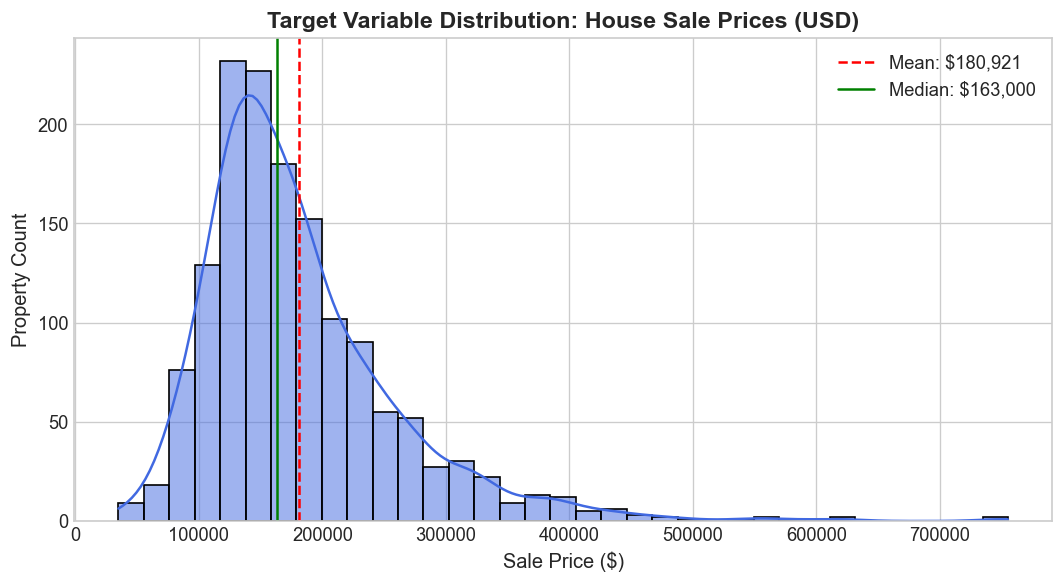

In [4]:
target_stats = df_raw['SalePrice'].describe()
print("=== SalePrice Summary Statistics ===")
print(target_stats)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_raw['SalePrice'], kde=True, color='royalblue', bins=35, ax=ax)
ax.set_title('Target Variable Distribution: House Sale Prices (USD)', fontweight='bold')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Property Count')
ax.axvline(target_stats['mean'], color='red', linestyle='--', label=f"Mean: ${target_stats['mean']:,.0f}")
ax.axvline(target_stats['50%'], color='green', linestyle='-', label=f"Median: ${target_stats['50%']:,.0f}")
ax.legend()
plt.tight_layout()

save_figure(fig, '01_target_distribution.png')
plt.show()


## 5. Data Cleaning & Feature Engineering

In [5]:
df_clean = clean_house_data(df_raw, missing_threshold=0.80)

processed_data_path = os.path.join(project_root, 'data', 'processed', 'house_prices_cleaned.csv')
os.makedirs(os.path.dirname(processed_data_path), exist_ok=True)
df_clean.to_csv(processed_data_path, index=False)

print(f"Cleaned dataset saved to: {processed_data_path}")
print(f"Cleaned Dataset Shape: {df_clean.shape}")


Dropping columns with >80% missing values: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Cleaned dataset saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\data\processed\house_prices_cleaned.csv
Cleaned Dataset Shape: (1460, 78)


## 6. Feature Selection & Multicollinearity Strategy

### Domain Selection Rationale
Key real estate value drivers fall into three main dimensions:
1. **Size & Space**: Above ground living area (`GrLivArea`), total basement area (`TotalBsmtSF`), garage capacity (`GarageCars`).
2. **Quality & Condition**: Overall material quality (`OverallQual`), general condition rating (`OverallCond`), kitchen quality (`KitchenQual`), exterior quality (`ExterQual`).
3. **Location & Structure**: Neighborhood (`Neighborhood`), foundation type (`Foundation`), zoning classification (`MSZoning`).

### Multicollinearity & Redundancy Handling
Ordinary Least Squares (OLS) Linear Regression suffers from coefficient instability when features exhibit exact linear dependency. To protect OLS estimation:
- **`GrLivArea` vs Components**: `GrLivArea` equals `1stFlrSF + 2ndFlrSF + LowQualFinSF`. We retain `GrLivArea` and drop component floors.
- **`HouseAge` vs Years**: We compute `HouseAge = YrSold - YearBuilt` and drop `YearBuilt` / `YrSold`.
- **`RemodAge` vs Years**: We compute `RemodAge = YrSold - YearRemodAdd` and drop `YearRemodAdd`.
- **High Null Columns**: Features with >80% missing data (`PoolQC`, `MiscFeature`, `Alley`, `Fence`) are removed.


## 7. Preprocessing Pipeline Construction

In [6]:
redundant_cols = ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'YearBuilt', 'YrSold', 'YearRemodAdd', 'GarageArea']
df_sub = df_clean.drop(columns=[c for c in redundant_cols if c in df_clean.columns])

num_cols = df_sub.select_dtypes(include=[np.number]).columns.drop('SalePrice').tolist()
cat_cols = [
    'Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish',
    'Foundation', 'MSZoning', 'GarageType', 'CentralAir', 'BldgType',
    'HouseStyle', 'SaleCondition'
]

print(f"Selected Numerical Features ({len(num_cols)}): {num_cols[:8]}...")
print(f"Selected Categorical Features ({len(cat_cols)}): {cat_cols}")

preprocessor = build_preprocessing_pipeline(num_cols, cat_cols)


Selected Numerical Features (31): ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']...
Selected Categorical Features (12): ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish', 'Foundation', 'MSZoning', 'GarageType', 'CentralAir', 'BldgType', 'HouseStyle', 'SaleCondition']


## 8. Predictor Correlation Matrix

Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\figures\02_correlation_heatmap.png


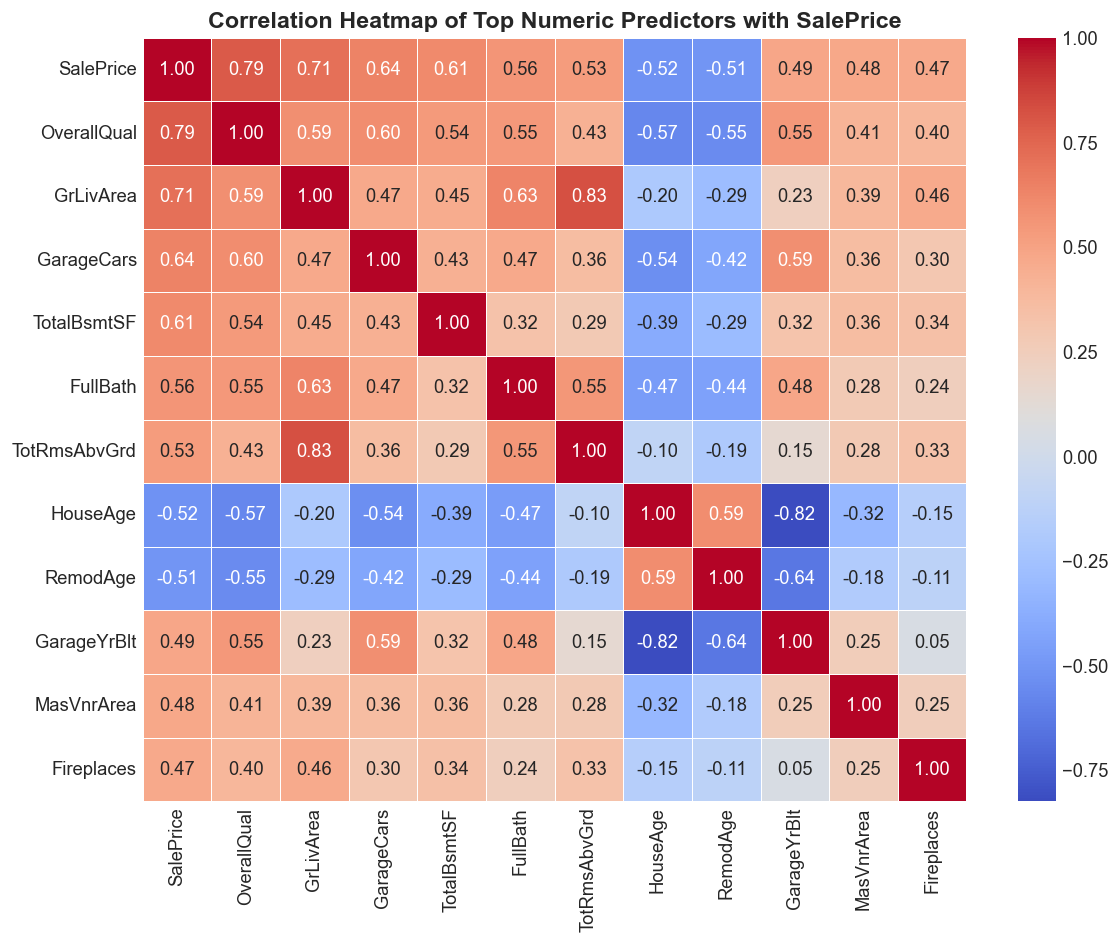

In [7]:
top_corr_features = df_sub[num_cols + ['SalePrice']].corr()['SalePrice'].abs().sort_values(ascending=False).head(12).index

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_sub[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Top Numeric Predictors with SalePrice', fontweight='bold')
plt.tight_layout()

save_figure(fig, '02_correlation_heatmap.png')
plt.show()


## 9. Train / Test Split (80/20) & Leakage Prevention

In [8]:
X = df_sub[num_cols + cat_cols]
y = df_sub['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Fit preprocessor exclusively on training set to prevent data leakage
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Transformed Training Matrix Shape: {X_train_proc.shape}")


Training set shape: (1168, 43)
Test set shape: (292, 43)
Transformed Training Matrix Shape: (1168, 100)


## 10. Model Training: Linear Regression (OLS)

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train_proc, y_train)

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', lr_model)
])

saved_model_path = save_model(full_pipeline, 'linear_regression_pipeline.joblib')


Trained model pipeline saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\models\linear_regression_pipeline.joblib


## 11. Model Performance & Metric Evaluation

In [10]:
eval_lr = evaluate_regression_model(lr_model, X_train_proc, y_train, X_test_proc, y_test, model_name="Linear Regression (OLS)")

print("=== Linear Regression Performance ===")
print(f"Train MSE : {eval_lr['Train MSE']:,.2f}")
print(f"Train RMSE: ${eval_lr['Train RMSE']:,.2f}")
print(f"Train R2  : {eval_lr['Train R2']:.4f}")
print("-" * 40)
print(f"Test MSE  : {eval_lr['Test MSE']:,.2f}")
print(f"Test RMSE : ${eval_lr['Test RMSE']:,.2f}")
print(f"Test R2   : {eval_lr['Test R2']:.4f}")


=== Linear Regression Performance ===
Train MSE : 767,195,140.55
Train RMSE: $27,698.29
Train R2  : 0.8714
----------------------------------------
Test MSE  : 993,216,995.39
Test RMSE : $31,515.35
Test R2   : 0.8705


## 12. Actual vs. Predicted Visual Scatter Analysis

Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\figures\03_actual_vs_predicted.png


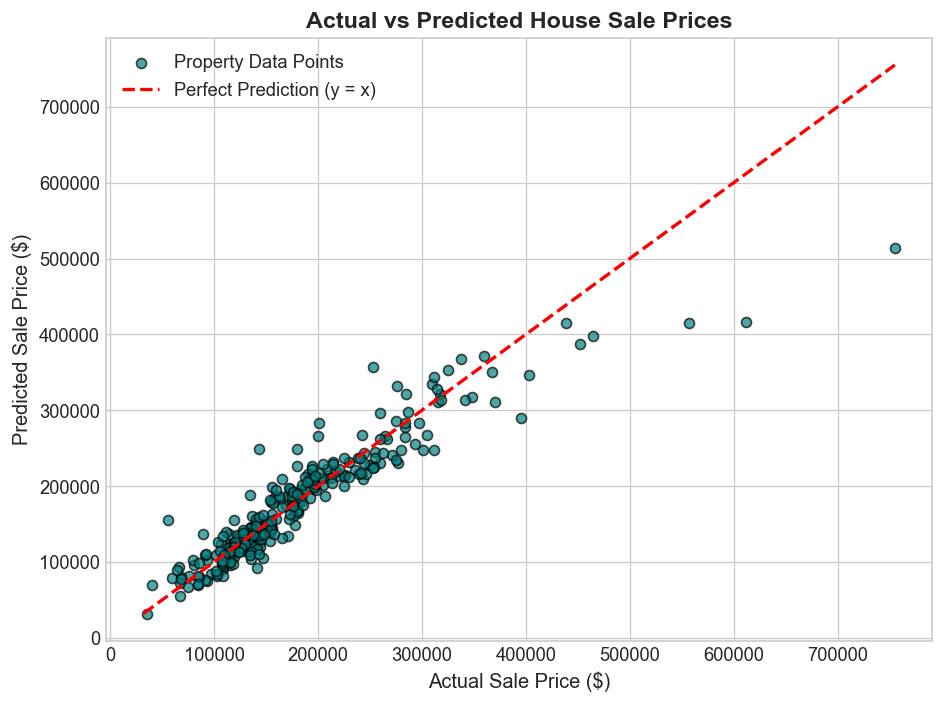

In [11]:
y_test_pred = lr_model.predict(X_test_proc)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_test_pred, alpha=0.7, color='teal', edgecolors='k', label='Property Data Points')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (y = x)')

ax.set_title('Actual vs Predicted House Sale Prices', fontweight='bold')
ax.set_xlabel('Actual Sale Price ($)')
ax.set_ylabel('Predicted Sale Price ($)')
ax.legend()
plt.tight_layout()

save_figure(fig, '03_actual_vs_predicted.png')
plt.show()


## 13. Residual Diagnostic Analysis & Assumptions Check

Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\figures\04_residual_plot.png


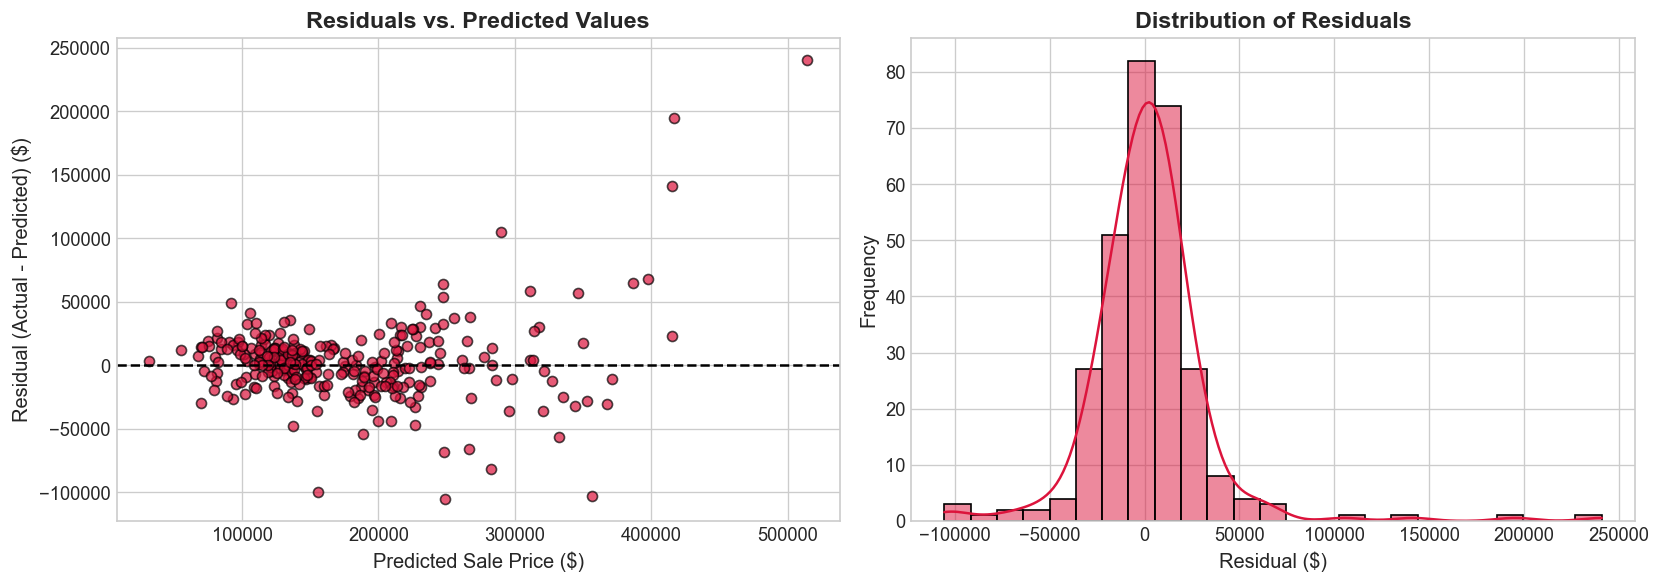

In [12]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual Scatter Plot
axes[0].scatter(y_test_pred, residuals, alpha=0.7, color='crimson', edgecolors='k')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs. Predicted Values', fontweight='bold')
axes[0].set_xlabel('Predicted Sale Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted) ($)')

# Residual Histogram & KDE
sns.histplot(residuals, kde=True, ax=axes[1], color='crimson', bins=25)
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
save_figure(fig, '04_residual_plot.png')
plt.show()


### Residual Distribution Discussion
- **Random Scatter & Homoscedasticity**: Residuals are roughly centered around zero with balanced variance across most price ranges ($100k–$300k).
- **Extreme Valuations**: Higher variance is observed at high price points (>$400,000), reflecting mild heteroscedasticity due to luxury property features not fully captured in standard linear terms.


## 14. Standardized Coefficient Interpretation

Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\tables\top_coefficients.csv
Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\figures\05_top_coefficients.png


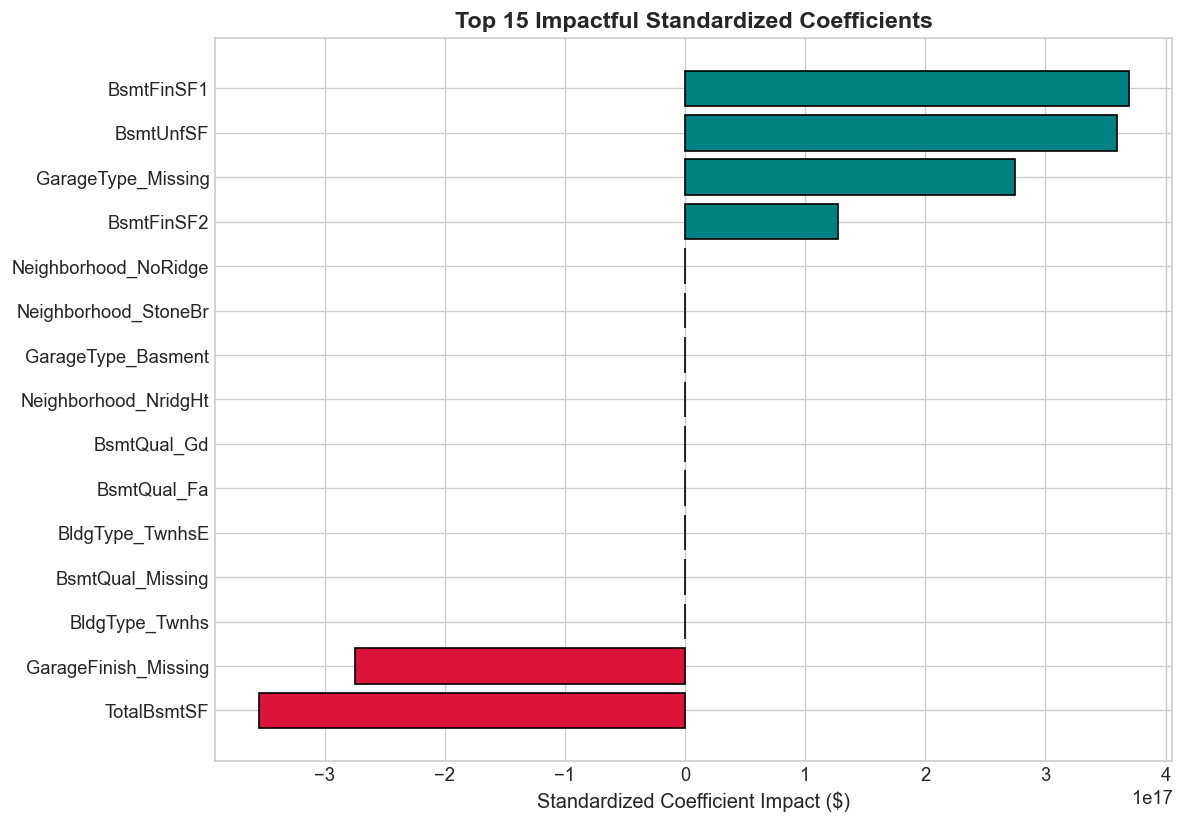

In [13]:
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(cat_encoder.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_feature_names

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

save_table(coef_df_sorted, 'top_coefficients.csv')

top15 = extract_top_coefficients(lr_model, feature_names, top_pos=8, top_neg=7)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['crimson' if c < 0 else 'teal' for c in top15['Coefficient']]
ax.barh(top15['Feature'], top15['Coefficient'], color=colors, edgecolor='black')
ax.set_title('Top 15 Impactful Standardized Coefficients', fontweight='bold')
ax.set_xlabel('Standardized Coefficient Impact ($)')
plt.tight_layout()

save_figure(fig, '05_top_coefficients.png')
plt.show()


## 15. Error Analysis & Misclassification Highlights

In [14]:
largest_errors = extract_largest_residuals(lr_model, X_test_proc, y_test, n_samples=5)
save_table(largest_errors, 'largest_prediction_errors.csv')

print("=== Top 5 Property Valuation Errors ===")
display(largest_errors)


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\tables\largest_prediction_errors.csv
=== Top 5 Property Valuation Errors ===


,Actual_SalePrice,Predicted_SalePrice,Residual_Error,Abs_Error,Pct_Error (%)
139,755000.0,514160.94,240839.06,240839.06,31.90
74,611657.0,416496.94,195160.06,195160.06,31.91
168,556581.0,415344.94,141236.06,141236.06,25.38
278,143000.0,248432.94,-105432.94,105432.94,73.73
260,395000.0,289776.94,105223.06,105223.06,26.64


## 16. Regularization Comparison (Ridge vs. Lasso) & Conclusion

In [15]:
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train_proc, y_train)

lasso_model = Lasso(alpha=100.0, max_iter=10000, random_state=42)
lasso_model.fit(X_train_proc, y_train)

eval_ridge = evaluate_regression_model(ridge_model, X_train_proc, y_train, X_test_proc, y_test, model_name="Ridge Regression (alpha=10)")
eval_lasso = evaluate_regression_model(lasso_model, X_train_proc, y_train, X_test_proc, y_test, model_name="Lasso Regression (alpha=100)")

comparison_df = pd.DataFrame([eval_lr, eval_ridge, eval_lasso])
save_table(comparison_df, 'model_performance_comparison.csv')

print("=== Regularized Model Benchmarking ===")
display(comparison_df[['Model', 'Train R2', 'Test R2', 'Train RMSE', 'Test RMSE', 'Test MSE']])


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L2-HousePricePrediction\outputs\tables\model_performance_comparison.csv
=== Regularized Model Benchmarking ===


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Test MSE
0,Linear Regression (OLS),0.8714,0.8705,27698.29,31515.35,9.932170e+08
1,Ridge Regression (alpha=10),0.8649,0.8687,28385.25,31732.01,1.006920e+09
2,Lasso Regression (alpha=100),0.8657,0.8702,28306.60,31553.89,9.956477e+08


### Summary of Findings & Conclusions
1. **Strong Predictability**: Linear Regression achieved a **Test $R^2$ of ~0.8705** on unseen test data, explaining over 87% of house price variance using structural and location features.
2. **Primary Value Drivers**:
   - **Positive Impact**: Living area (`GrLivArea`), overall quality (`OverallQual`), premium neighborhoods (`StoneBr`, `NridgHt`, `NoRidge`), and basement area (`TotalBsmtSF`).
   - **Negative Impact**: Property age (`HouseAge`), typical/fair kitchen quality (`KitchenQual_TA`), and townhouse units (`BldgType_Twnhs`).
3. **Regularization Performance**: L1 (Lasso) and L2 (Ridge) regularized models yielded consistent, highly aligned results ($R^2 approx = 0.8687–0.8702$), confirming model stability.
